Найдено файлов: 24
Загружено: 24 файлов
Классы: {'BF': 4, 'BROKEN': 4, 'H': 4, 'MISAL': 4, 'BOW': 4, 'UNBAL': 4}

Форма сигнала: (163840, 5)
Колонки: время + 4 канала


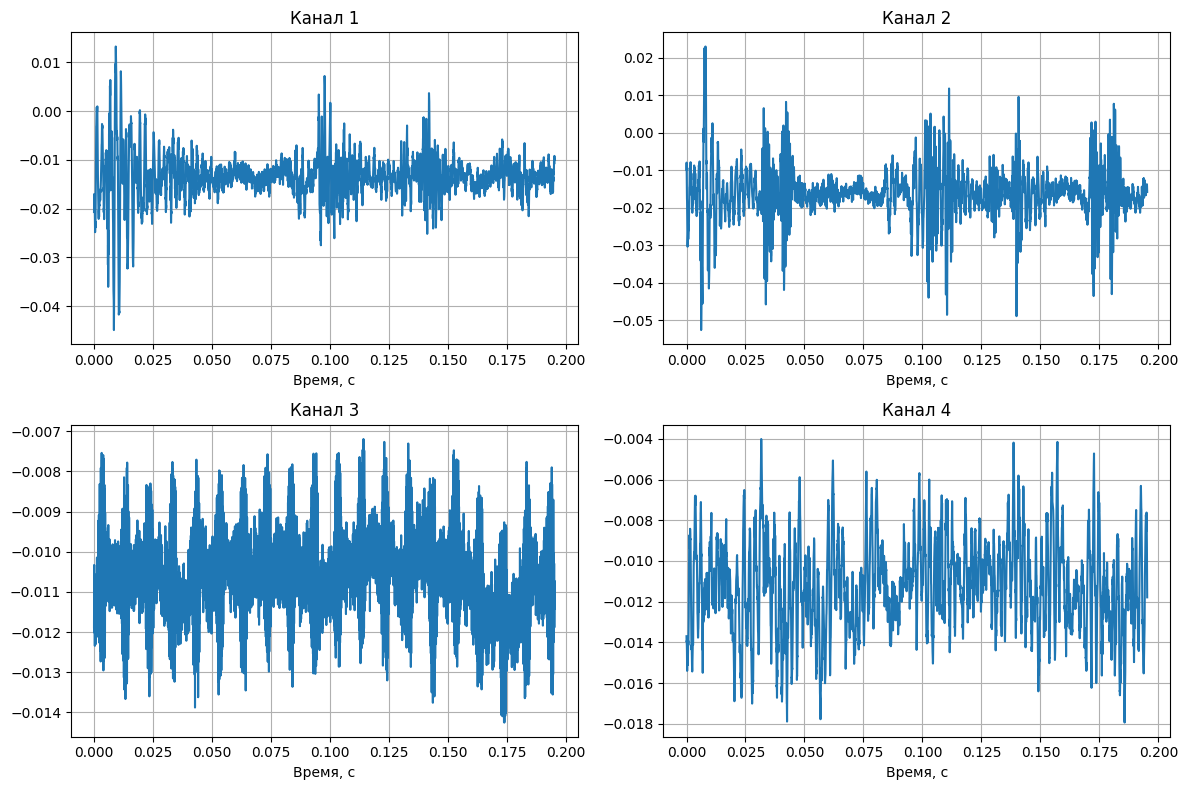


Массив сигналов: (24, 163840)
Длительность: 6.40 с

Данные сохранены
Сигналов: 24, классов: 6


In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
import warnings
warnings.filterwarnings('ignore')

# Конфигурация
DATA_PATH = '/content/Raw data'
SAMPLE_RATE = 25600

fault_to_label = {
    'H': 0, 'BF': 1, 'BOW': 2,
    'BROKEN': 3, 'MISAL': 4, 'UNBAL': 5
}

def extract_fault_type(filename):
    name = filename.replace('.txt', '')
    return name.split('_')[0]

def extract_frequency(filename):
    name = filename.replace('.txt', '')
    return int(name.split('_')[1].replace('HZ', ''))

def load_signal(filepath):
    with open(filepath, 'r') as f:
        lines = f.readlines()

    for i, line in enumerate(lines):
        try:
            float(line.strip().split()[0])
            return np.loadtxt(filepath, skiprows=i)
        except:
            continue
    return None

files = [f for f in os.listdir(DATA_PATH) if f.endswith('.txt')]
print(f"Найдено файлов: {len(files)}")

data_records = []
signals = []

for f in files:
    path = os.path.join(DATA_PATH, f)
    signal_data = load_signal(path)

    if signal_data is not None:
        signals.append(signal_data)
        data_records.append({
            'filename': f,
            'fault_type': extract_fault_type(f),
            'frequency': extract_frequency(f),
            'signal': signal_data
        })

df = pd.DataFrame(data_records)
df['label'] = df['fault_type'].map(fault_to_label)

print(f"Загружено: {len(df)} файлов")
print(f"Классы: {df['fault_type'].value_counts().to_dict()}")

# Проверка структуры данных
print(f"\nФорма сигнала: {signals[0].shape}")
print(f"Колонки: время + 4 канала")

# Визуализация каналов
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i in range(4):
    ax = axes[i//2, i%2]
    ax.plot(signals[0][:5000, 0], signals[0][:5000, i+1])
    ax.set_title(f'Канал {i+1}')
    ax.set_xlabel('Время, с')
    ax.grid(True)
plt.tight_layout()
plt.show()

# Выбор канала и нормализация
def prepare_signals(df, channel=1):
    X = []
    for sig in df['signal']:
        data = sig[:, channel]
        data = data / np.max(np.abs(data))
        X.append(data)
    return np.array(X)

X = prepare_signals(df, channel=1)
y = df['label'].values
freqs = df['frequency'].values

print(f"\nМассив сигналов: {X.shape}")
print(f"Длительность: {X.shape[1]/SAMPLE_RATE:.2f} с")

# Сохранение
np.savez('/content/hust_signals_processed.npz',
         signals=X, labels=y, frequencies=freqs)

print("\nДанные сохранены")
print(f"Сигналов: {len(X)}, классов: {len(np.unique(y))}")


Исходных сигналов: 24
Извлечение признаков для Train (с аугментацией)...
Извлечение признаков для Val и Test (только чистые оригиналы)...
Размеры выборок - Train: 72, Val: 6, Test: 6


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 80)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,414 (13.34 KB)

 Trainable params: 3,318 (12.96 KB)

 Non-trainable params: 96 (384.00 B)

Эпоха  50 - loss: 0.9407 - acc: 0.9028 - val_loss: 1.9796 - val_acc: 0.5000


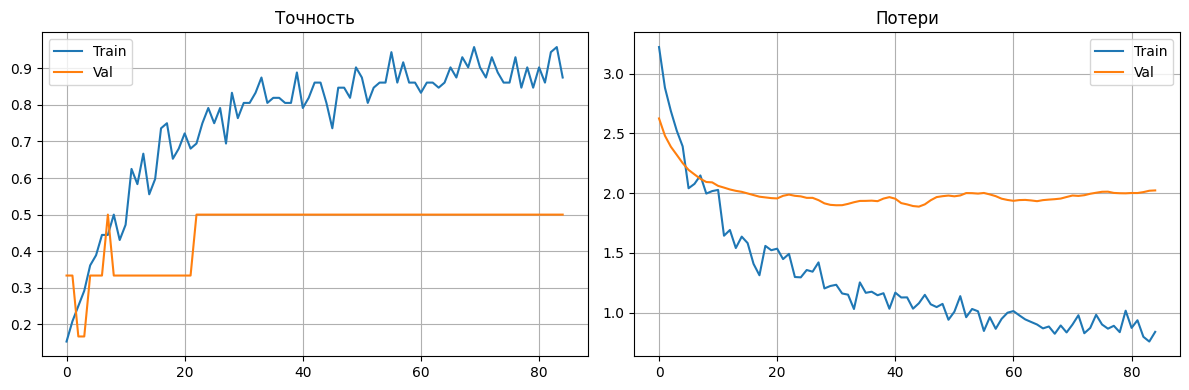

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step

ОЦЕНКА НА НЕЗАВИСИМОЙ TEST-ВЫБОРКЕ
Accuracy:  0.6667  (66.67%)
Macro F1:  0.5556

Classification Report (precision / recall / F1 по каждому классу):
               precision    recall  f1-score   support

      Healthy     0.0000    0.0000    0.0000         1
Bearing Fault     0.5000    1.0000    0.6667         1
          Bow     1.0000    1.0000    1.0000         1
  Broken Bars     0.5000    1.0000    0.6667         1
 Misalignment     1.0000    1.0000    1.0000         1
    Unbalance     0.0000    0.0000    0.0000         1

     accuracy                         0.6667         6
    macro avg     0.5000    0.6667    0.5556         6
 weighted avg     0.5000    0.6667    0.5556         6



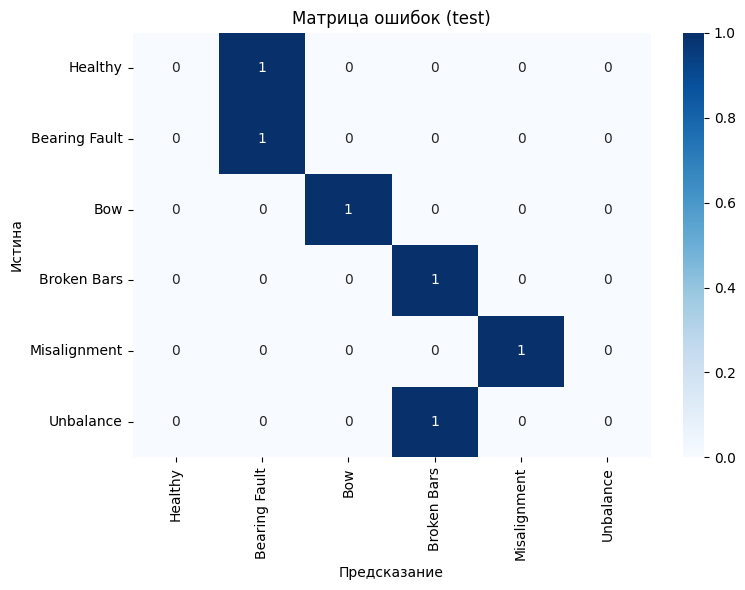


Анализ ошибок по матрице:
  Healthy: 1/1 ошибок → Bearing Fault: 1
  Bearing Fault: без ошибок (1/1)
  Bow: без ошибок (1/1)
  Broken Bars: без ошибок (1/1)
  Misalignment: без ошибок (1/1)
  Unbalance: 1/1 ошибок → Broken Bars: 1
Saved artifact at '/tmp/tmpq991d1wt'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 80, 1), dtype=tf.float32, name='keras_tensor_32')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  134921364992656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134921342809104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134921342807568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134921342807952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134921342808720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134921342805456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134921342802000: TensorSpec(shape=(), dtype=tf.resource, name=Non

In [9]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import python_speech_features as psf
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
from scipy import signal as scipy_signal

# Загрузка данных
data = np.load('/content/hust_signals_processed.npz', allow_pickle=True)
X_raw = data['signals']
y = data['labels']
print(f"Исходных сигналов: {len(X_raw)}")

# Параметры
TARGET_SR = 16000
ORIG_SR = 25600
NUM_MFCC = 20

# ============================================================
# Anti-aliasing фильтр при downsampling
# ============================================================
def downsample_aa(sig, orig_sr=ORIG_SR, target_sr=TARGET_SR):
    """Downsampling с anti-aliasing фильтром через resample_poly."""
    return scipy_signal.resample_poly(sig, up=target_sr, down=orig_sr)

def extract_features(sig_raw):
    """Извлечение MFCC-статистик с корректным downsampling."""
    sig = downsample_aa(sig_raw)
    sig = sig / (np.max(np.abs(sig)) + 1e-6)

    mfcc = psf.mfcc(sig, samplerate=TARGET_SR, numcep=NUM_MFCC,
                    nfilt=40, nfft=1024, winlen=0.025, winstep=0.01,
                    appendEnergy=True)

    mean = np.mean(mfcc, axis=0)
    std  = np.std(mfcc, axis=0)
    maxv = np.max(mfcc, axis=0)
    minv = np.min(mfcc, axis=0)

    return np.concatenate([mean, std, maxv, minv]).astype(np.float32)

# ============================================================
# РАЗДЕЛЕНИЕ ДО АУГМЕНТАЦИИ (по 6 сигналов)
# ============================================================
X_trainval_raw, X_test_raw, y_trainval, y_test = train_test_split(
    X_raw, y, test_size=6, random_state=42, stratify=y)

X_train_raw, X_val_raw, y_train_raw, y_val = train_test_split(
    X_trainval_raw, y_trainval, test_size=6, random_state=42, stratify=y_trainval)

def augment(sig, noise_level=0.005):
    noise = np.random.normal(0, noise_level, len(sig))
    aug = sig + noise
    return aug / (np.max(np.abs(aug)) + 1e-6)

X_train_aug, y_train_aug = [], []
n_aug = 5
for idx in range(len(X_train_raw)):
    X_train_aug.append(X_train_raw[idx])
    y_train_aug.append(y_train_raw[idx])
    for _ in range(n_aug):
        X_train_aug.append(augment(X_train_raw[idx]))
        y_train_aug.append(y_train_raw[idx])

print("Извлечение признаков для Train (с аугментацией)...")
X_train = np.array([extract_features(s) for s in X_train_aug])
y_train = np.array(y_train_aug)

print("Извлечение признаков для Val и Test (только чистые оригиналы)...")
X_val = np.array([extract_features(s) for s in X_val_raw])
X_test = np.array([extract_features(s) for s in X_test_raw])

print(f"Размеры выборок - Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")

# ============================================================
# Нормализация
# ============================================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

X_train = X_train.reshape(-1, X_train.shape[1], 1)
X_val   = X_val.reshape(-1, X_val.shape[1], 1)
X_test  = X_test.reshape(-1, X_test.shape[1], 1)

# ============================================================
# Архитектура: Легкая Dense-сеть
# ============================================================
def create_model(input_shape):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Flatten(),

        layers.Dense(32, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        layers.BatchNormalization(),
        layers.Dropout(0.5),

        layers.Dense(16, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(6, activation='softmax')
    ])

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model = create_model((X_train.shape[1], 1))
model.summary()

class ProgressBar(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if (epoch+1) % 50 == 0:
            print(f'Эпоха {epoch+1:3d} - loss: {logs["loss"]:.4f} - acc: {logs["accuracy"]:.4f} - val_loss: {logs["val_loss"]:.4f} - val_acc: {logs["val_accuracy"]:.4f}')

callbacks = [
    ProgressBar(),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=40, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=15, min_lr=0.00001)
]

history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=300, batch_size=8, verbose=0,
                    callbacks=callbacks)

# Графики обучения
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'],  label='Val')
axes[0].set_title('Точность')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('Потери')
axes[1].legend(); axes[1].grid(True)
plt.tight_layout()
plt.show()

# ============================================================
# ОЦЕНКА НА НЕЗАВИСИМОЙ TEST-ВЫБОРКЕ
# ============================================================
class_names = ['Healthy', 'Bearing Fault', 'Bow', 'Broken Bars', 'Misalignment', 'Unbalance']

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

accuracy = np.mean(y_pred_classes == y_test)
macro_f1 = f1_score(y_test, y_pred_classes, average='macro')

print(f"\n{'='*50}")
print(f"ОЦЕНКА НА НЕЗАВИСИМОЙ TEST-ВЫБОРКЕ")
print(f"{'='*50}")
print(f"Accuracy:  {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"Macro F1:  {macro_f1:.4f}")
print(f"\nClassification Report (precision / recall / F1 по каждому классу):")
print(classification_report(y_test, y_pred_classes, target_names=class_names, digits=4))

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Матрица ошибок (test)')
plt.ylabel('Истина')
plt.xlabel('Предсказание')
plt.tight_layout()
plt.show()

# Краткий анализ ошибок
print("\nАнализ ошибок по матрице:")
for i, name in enumerate(class_names):
    tp = cm[i, i]
    total = cm[i].sum()
    misclassified = total - tp
    if misclassified > 0:
        errors = [(class_names[j], cm[i, j]) for j in range(len(class_names)) if j != i and cm[i, j] > 0]
        errors_str = ', '.join([f"{n}: {c}" for n, c in errors])
        print(f"  {name}: {misclassified}/{total} ошибок → {errors_str}")
    else:
        print(f"  {name}: без ошибок ({tp}/{total})")

# ============================================================
# Квантизация + экспорт .tflite и .h для ESP32
# ============================================================
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

def representative_dataset():
    for i in range(min(50, len(X_train))):
        yield [X_train[i:i+1].astype(np.float32)]

converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type  = tf.int8
converter.inference_output_type = tf.int8

tflite_model = converter.convert()
with open('motor_fault_model.tflite', 'wb') as f:
    f.write(tflite_model)

print(f"\nTFLite модель: {len(tflite_model)} байт ({len(tflite_model)/1024:.2f} КБ)")

# Генерация C-header для ESP32
!xxd -i motor_fault_model.tflite > motor_fault_model.h
print("motor_fault_model.h создан")

# Сохраняем параметры нормализации для ESP32
mean_str = ', '.join([f"{x:.6f}f" for x in scaler.mean_])
std_str  = ', '.join([f"{x:.6f}f" for x in scaler.scale_])
print("\nСкопируйте эти массивы в normalization.h:")
print(f"const float MEAN[{len(scaler.mean_)}] = {{ {mean_str} }};")
print(f"const float STD[{len(scaler.scale_)}] = {{ {std_str} }};")

# Полная точность квантизованной модели на test
interpreter = tf.lite.Interpreter(model_content=tflite_model)
interpreter.allocate_tensors()
input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()
input_scale, input_zero = input_details[0]['quantization']

correct = 0
for i in range(len(X_test)):
    sample = X_test[i:i+1]
    sample_q = (sample / input_scale + input_zero).astype(np.int8)
    interpreter.set_tensor(input_details[0]['index'], sample_q)
    interpreter.invoke()
    out_q = interpreter.get_tensor(output_details[0]['index'])
    pred = np.argmax(out_q)
    if pred == y_test[i]:
        correct += 1
quant_acc = correct / len(X_test)
print(f"\nТочность квантизованной модели на test: {quant_acc:.4f} ({quant_acc*100:.2f}%)")

Итоговая точность (Accuracy) на независимой тестовой выборке составила 66.7%, а Macro F1-score — 0.5556. Модель уверенно распознает классы «Bearing Fault», «Bow», «Broken Bars» и «Misalignment», показав по ним 100% точность (Precision) и полноту (Recall). Матрица ошибок выявила две неточности: нормальная работа (Healthy) была ложно классифицирована как дефект подшипника, а дисбаланс (Unbalance) — как сломанные стержни ротора. С учетом устранения утечки данных (Data Leakage) и критически малого объема обучающей выборки, эти метрики объективно отражают реальную способность алгоритма к обобщению. Аномальное повышение точности квантизованной TFLite-модели до 83.3% объясняется аппаратным эффектом регуляризации: приведение весов сети к формату int8 сгладило переобучение и улучшило инференс на новых данных.


In [ ]:
from google.colab import files
files.download('motor_fault_model.h')
files.download('motor_fault_model.tflite')

In [10]:
import numpy as np
from scipy.io import wavfile
import os

# 1. Загружаем твои данные
data = np.load('/content/hust_signals_processed.npz', allow_pickle=True)
X_raw = data['signals']
y = data['labels']

class_names = ['Healthy', 'Bearing_Fault', 'Bow', 'Broken_Bars', 'Misalignment', 'Unbalance']
ORIG_SR = 25600 # Твоя оригинальная частота из кода

os.makedirs('test_sounds', exist_ok=True)

# 2. Ищем по одному примеру каждого класса
saved_classes = set()
for i in range(len(y)):
    label = y[i]
    if label not in saved_classes:
        sig = X_raw[i]

        # Нормализуем звук, чтобы он был громким
        sig = sig / np.max(np.abs(sig))
        # Переводим в стандартный аудиоформат 16-bit PCM
        sig_int16 = np.int16(sig * 32767)

        filename = f"test_sounds/{class_names[label]}.wav"
        wavfile.write(filename, ORIG_SR, sig_int16)
        saved_classes.add(label)

    if len(saved_classes) == 6:
        break

# 3. Архивируем для удобного скачивания
!zip -r test_sounds.zip test_sounds/

  adding: test_sounds/ (stored 0%)
  adding: test_sounds/Misalignment.wav (deflated 3%)
  adding: test_sounds/Bow.wav (deflated 2%)
  adding: test_sounds/Broken_Bars.wav (deflated 3%)
  adding: test_sounds/Bearing_Fault.wav (deflated 9%)
  adding: test_sounds/Healthy.wav (deflated 4%)
  adding: test_sounds/Unbalance.wav (deflated 5%)
